# Exploratory Data Analysis (EDA) — Sales Dataset

This notebook performs a complete **EDA (Exploratory Data Analysis)** using `matplotlib` and `seaborn` on the cleaned sales dataset.

We cover:
1. Data Loading & Quick Cleaning (so the plots are meaningful)
2. **Univariate Analysis** — distribution of single variables
3. **Bivariate Analysis** — relationship between two variables
4. **Multivariate Analysis** — relationship between 3+ variables

Each chart has a clear title, labels, and a comment explaining *why* we're plotting it and *what insight* it gives.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot style settings for clean, consistent visuals
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

In [3]:
df = pd.read_csv('22. messy_sales_data.csv')

In [4]:
df.head()

,OrderID,CustomerID,CustomerName,City,Category,PaymentMode,Price,Quantity,DiscountPct,Rating,OrderDate,CustomerAge,Email,Phone,ReviewText
0,ORD51058,CUST04879,Chaitanya Mane,bangalore,Grocery,net_banking,904.48,3.0,10,3.3,2023-04-24,29.0,chaitanya.mane@gmail.com,9454663439,Packaging was bad
1,ORD70248,CUST00177,Siddharth Sha,DELHI,SPORTS,Net Banking,1823.76,4.0,20,5.0,04-01-2023,38.0,NaN,NaN,great service
2,ORD43804,CUST04537,Nathaniel Chatterjee,chennai,electronic,Upi,770.67,1.0,0,4.9,11/17/2024,40.0,nathaniel.chatterjee@outlook.com,9573975601,Okayish product
3,ORD46367,CUST07605,pranit contractor,Jaipur,Clothing,COD,2028.06,1.0,0,2.9,NaN,41.0,pranit.contractor@rediffmail.com,9235766629,NaN
4,ORD32922,CUST03180,Hemang Chakraborty,Amdavad,FURNITURE,cc,604.00,4.0,10,3.7,14 Jan 2023,44.0,hemang.chakraborty@outlook.com,9731250657,Superb!!! fast delivery


In [5]:
# --- Missing values ---
df['City'] = df['City'].fillna('Unknown')
df['PaymentMode'] = df['PaymentMode'].fillna(df['PaymentMode'].mode()[0])

# --- Duplicates ---
df = df.drop_duplicates()
dup_mask = df['OrderID'].duplicated(keep='first')
df.loc[dup_mask, 'OrderID'] = df.loc[dup_mask, 'OrderID'] + '_DUP' + df.loc[dup_mask].groupby('OrderID').cumcount().astype(str)

# --- String cleaning ---
df['CustomerName'] = df['CustomerName'].str.strip().str.title()

df['City'] = df['City'].str.strip().str.lower()
city_map = {
    'mumbai': 'Mumbai', 'bombay': 'Mumbai',
    'delhi': 'Delhi', 'new delhi': 'Delhi',
    'bangalore': 'Bangalore', 'bengaluru': 'Bangalore', 'banglore': 'Bangalore',
    'chennai': 'Chennai', 'madras': 'Chennai',
    'kolkata': 'Kolkata', 'calcutta': 'Kolkata',
    'hyderabad': 'Hyderabad',
    'pune': 'Pune', 'poona': 'Pune',
    'ahmedabad': 'Ahmedabad', 'amdavad': 'Ahmedabad',
    'jaipur': 'Jaipur',
    'lucknow': 'Lucknow',
    'unknown': 'Unknown'
}
df['City'] = df['City'].map(city_map).fillna(df['City'].str.title())

df['Category'] = df['Category'].str.strip().str.lower().str.rstrip('s')
df['Category'] = df['Category'].replace({'electronic': 'electronics'})
df['Category'] = df['Category'].str.title()

payment_map = {
    'credit card': 'Credit Card', 'cc': 'Credit Card', 'credit_card': 'Credit Card',
    'debit card': 'Debit Card', 'dc': 'Debit Card',
    'upi': 'UPI',
    'cod': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery',
    'net banking': 'Net Banking', 'netbanking': 'Net Banking', 'net_banking': 'Net Banking'
}
df['PaymentMode'] = df['PaymentMode'].str.strip().str.lower().map(payment_map)

# --- Numeric cleaning ---
df['Price'] = df['Price'].astype(str).str.replace(r'[₹,]', '', regex=True).str.replace('Rs.', '', regex=False).str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').abs()

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').abs()

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.loc[(df['Rating'] < 0) | (df['Rating'] > 5), 'Rating'] = np.nan

df['CustomerAge'] = pd.to_numeric(df['CustomerAge'], errors='coerce')
df.loc[(df['CustomerAge'] < 10) | (df['CustomerAge'] > 100), 'CustomerAge'] = np.nan

# --- Fill remaining numeric NaNs ---
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median()).astype(int)
df['Rating'] = df['Rating'].fillna(df.groupby('Category')['Rating'].transform('mean'))
df['CustomerAge'] = df['CustomerAge'].fillna(df['CustomerAge'].median()).astype(int)

# --- Dates ---
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)
df['OrderDate'] = df['OrderDate'].fillna(df['OrderDate'].median())

# --- Rename to snake_case ---
df = df.rename(columns={
    'OrderID': 'order_id', 'CustomerID': 'customer_id', 'CustomerName': 'customer_name',
    'City': 'city', 'Category': 'category', 'PaymentMode': 'payment_mode',
    'Price': 'price', 'Quantity': 'quantity', 'DiscountPct': 'discount_pct',
    'Rating': 'rating', 'OrderDate': 'order_date', 'CustomerAge': 'customer_age',
    'Email': 'email', 'Phone': 'phone', 'ReviewText': 'review_text'
})

# --- Feature engineering needed for plots ---
df['total_price'] = (df['price'] * df['quantity']).round(2)
df['discount_amount'] = (df['total_price'] * df['discount_pct'] / 100).round(2)
df['final_price'] = (df['total_price'] - df['discount_amount']).round(2)

df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_weekday'] = df['order_date'].dt.day_name()

bins = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (105519, 23)


C:\Users\amitm\AppData\Local\Temp\ipykernel_8492\3645382254.py:61: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)


,order_id,customer_id,customer_name,city,category,payment_mode,price,quantity,discount_pct,rating,...,phone,review_text,total_price,discount_amount,final_price,order_year,order_month,order_month_name,order_weekday,age_group
0,ORD51058,CUST04879,Chaitanya Mane,Bangalore,Grocery,Net Banking,904.48,3,10,3.3,...,9454663439,Packaging was bad,2713.44,271.34,2442.10,2023,4,April,Monday,26-35
1,ORD70248,CUST00177,Siddharth Sha,Delhi,Sport,Net Banking,1823.76,4,20,5.0,...,NaN,great service,7295.04,1459.01,5836.03,2024,1,January,Tuesday,36-50
2,ORD43804,CUST04537,Nathaniel Chatterjee,Chennai,Electronics,UPI,770.67,1,0,4.9,...,9573975601,Okayish product,770.67,0.00,770.67,2024,1,January,Tuesday,36-50
3,ORD46367,CUST07605,Pranit Contractor,Jaipur,Clothing,Cash on Delivery,2028.06,1,0,2.9,...,9235766629,NaN,2028.06,0.00,2028.06,2024,1,January,Tuesday,36-50
4,ORD32922,CUST03180,Hemang Chakraborty,Ahmedabad,Furniture,Credit Card,604.00,4,10,3.7,...,9731250657,Superb!!! fast delivery,2416.00,241.60,2174.40,2024,1,January,Tuesday,36-50


## 2. Univariate Analysis

Univariate analysis looks at **one variable at a time** — its distribution, spread, and most common values.

### 2.1 Price Distribution — Histogram + Distribution Curve (KDE)

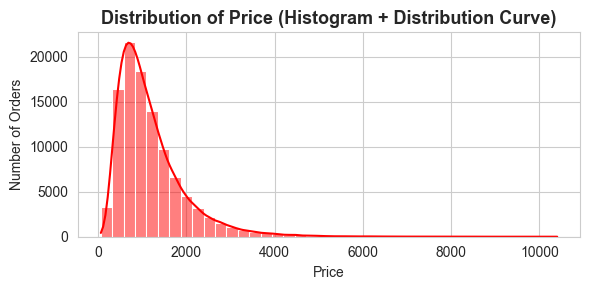

In [19]:
# A histogram shows how prices are spread out, and the KDE line on top
# gives a smooth distribution curve to see the overall shape (skew, peak, etc.)
plt.figure(figsize=(6, 3))
sns.histplot(df['price'], bins=40,kde=True,color='red')
plt.title('Distribution of Price (Histogram + Distribution Curve)')
plt.xlabel('Price')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

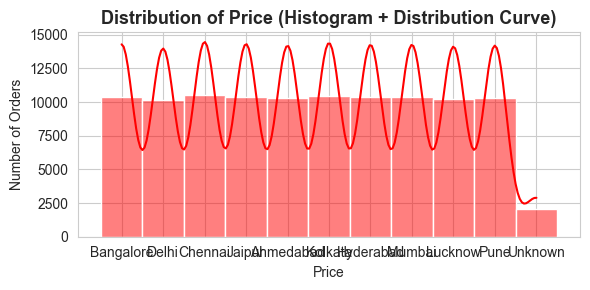

In [10]:
plt.figure(figsize=(6, 3))
sns.histplot(df['city'], bins=40,kde=True,color='red')
plt.title('Distribution of Price (Histogram + Distribution Curve)')
plt.xlabel('Price')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### 2.2 Customer Age Distribution — Distribution Curve

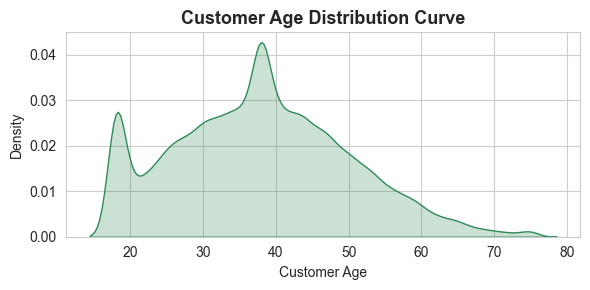

In [13]:
# A pure KDE (distribution curve) shows the smooth shape of the age distribution
# without the blockiness of a histogram, useful for spotting the central tendency
plt.figure(figsize=(6, 3))
sns.kdeplot(df['customer_age'], fill=True, color='seagreen')
plt.title('Customer Age Distribution Curve')
plt.xlabel('Customer Age')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

### 2.3 Rating Distribution — Histogram

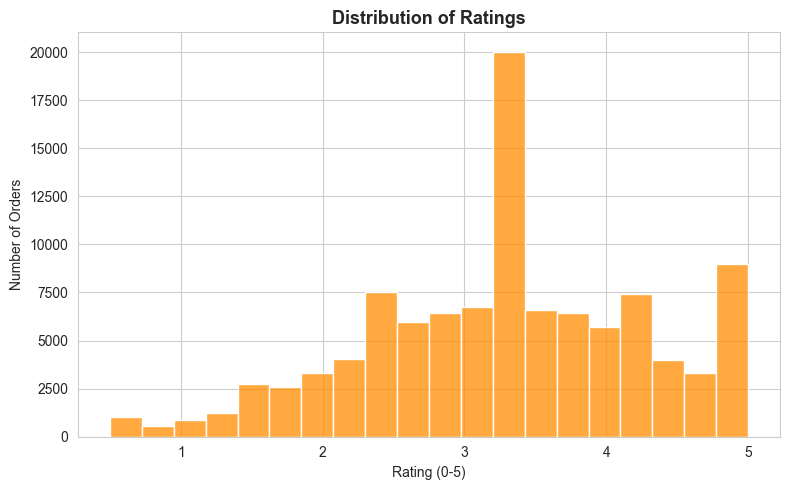

In [16]:
# Ratings are on a fixed 0-5 scale, so a histogram shows us how customers rated
# their orders overall - are most ratings high, low, or spread out evenly?
plt.figure(figsize=(8, 5))
sns.histplot(df['rating'], bins=20, color='darkorange')
plt.title('Distribution of Ratings')
plt.xlabel('Rating (0-5)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### 2.4 Category — Count Plot

In [22]:
df["category"].value_counts().index

Index(['Clothing', 'Furniture', 'Toy', 'Beauty', 'Electronics', 'Sport',
       'Book', 'Grocery', 'Grocerie'],
      dtype='str', name='category')

In [26]:
df["category"].value_counts()

category
Clothing       13309
Furniture      13269
Toy            13207
Beauty         13188
Electronics    13187
Sport          13154
Book           13122
Grocery         9844
Grocerie        3239
Name: count, dtype: int64

C:\Users\amitm\AppData\Local\Temp\ipykernel_8492\2012924845.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=order, palette='viridis')


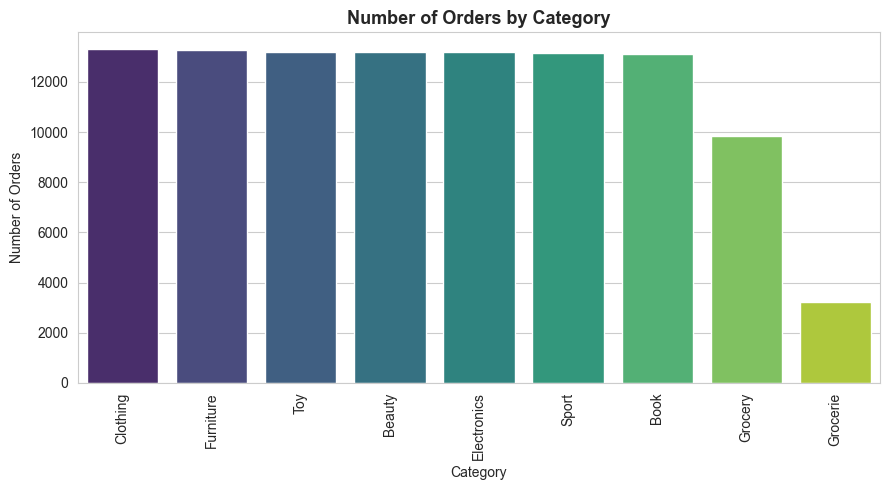

In [25]:
# A count plot tells us which product categories get ordered the most
plt.figure(figsize=(9, 5))

order = df['category'].value_counts().index

sns.countplot(data=df, x='category', order=order, palette='viridis')
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\amitm\AppData\Local\Temp\ipykernel_8492\1358501440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='city', order=order, palette='viridis')


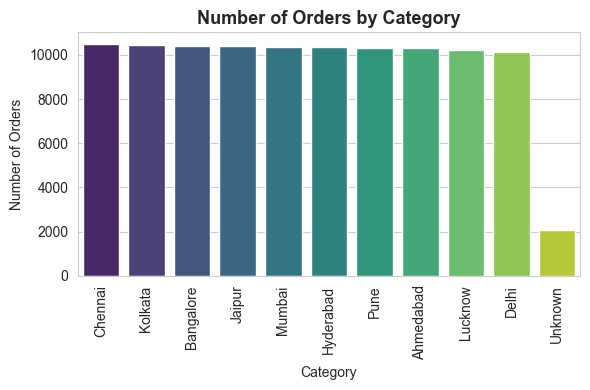

In [29]:
plt.figure(figsize=(6, 4))

order = df['city'].value_counts().index

sns.countplot(data=df, x='city', order=order, palette='viridis')
plt.title('Number of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [28]:
df.head()

,order_id,customer_id,customer_name,city,category,payment_mode,price,quantity,discount_pct,rating,...,phone,review_text,total_price,discount_amount,final_price,order_year,order_month,order_month_name,order_weekday,age_group
0,ORD51058,CUST04879,Chaitanya Mane,Bangalore,Grocery,Net Banking,904.48,3,10,3.3,...,9454663439,Packaging was bad,2713.44,271.34,2442.10,2023,4,April,Monday,26-35
1,ORD70248,CUST00177,Siddharth Sha,Delhi,Sport,Net Banking,1823.76,4,20,5.0,...,NaN,great service,7295.04,1459.01,5836.03,2024,1,January,Tuesday,36-50
2,ORD43804,CUST04537,Nathaniel Chatterjee,Chennai,Electronics,UPI,770.67,1,0,4.9,...,9573975601,Okayish product,770.67,0.00,770.67,2024,1,January,Tuesday,36-50
3,ORD46367,CUST07605,Pranit Contractor,Jaipur,Clothing,Cash on Delivery,2028.06,1,0,2.9,...,9235766629,NaN,2028.06,0.00,2028.06,2024,1,January,Tuesday,36-50
4,ORD32922,CUST03180,Hemang Chakraborty,Ahmedabad,Furniture,Credit Card,604.00,4,10,3.7,...,9731250657,Superb!!! fast delivery,2416.00,241.60,2174.40,2024,1,January,Tuesday,36-50


### 2.5 Category Share — Pie Chart

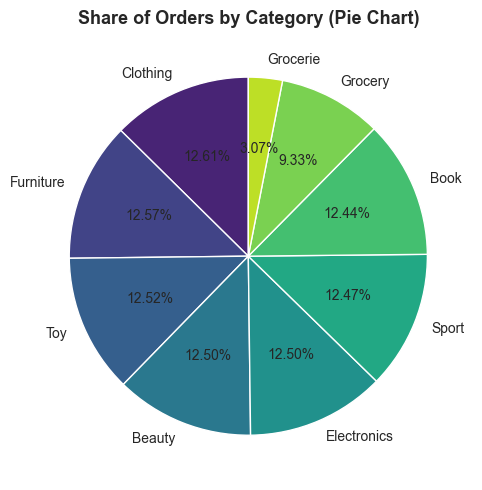

In [31]:
# A pie chart shows the proportion (%) each category contributes to total orders
category_counts = df['category'].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(category_counts, labels=category_counts.index, autopct='%1.2f%%',
        startangle=90, colors=sns.color_palette('viridis', len(category_counts)))

plt.title('Share of Orders by Category (Pie Chart)')
plt.tight_layout()
plt.show()

### 2.6 Payment Mode Share — Donut Chart

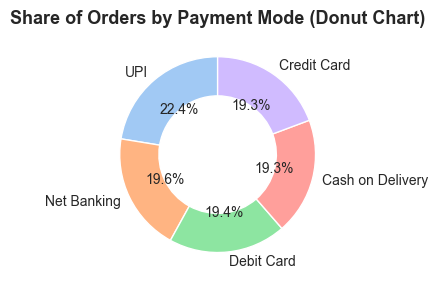

In [35]:
# A donut chart is the same idea as a pie chart, but with a hole in the middle -
# it looks cleaner and is popular for showing the payment method mix
payment_counts = df['payment_mode'].value_counts()

plt.figure(figsize=(4, 4))

wedges, texts, autotexts= plt.pie(
    payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
    startangle=90, colors=sns.color_palette('pastel', len(payment_counts)),
    wedgeprops=dict(width=0.4)   # this creates the "donut hole"
)
plt.title('Share of Orders by Payment Mode (Donut Chart)')
plt.tight_layout()
plt.show()

In [36]:
a, b, c = ("red", "black", "orange")

In [37]:
a

'red'